# CS231.Q21.KHTN
## Group 1

# PhoBERT Fine-tuning for Named Entity Recognition (NER)
### VLSP 2018 Vietnamese NER Dataset

This notebook fine-tunes [PhoBERT](https://github.com/VinAIResearch/PhoBERT) on the VLSP2018 NER dataset.  
It runs on both **local CPU** and **Google Colab (T4 GPU)**.

**Entity types:** `PER` · `ORG` · `LOC` · `MISC`  
**Label scheme:** BIO (Beginning / Inside / Outside)

## 1. Environment Setup

In [1]:
import sys, subprocess

# ── Detect environment ────────────────────────────────────────────────────────
IN_COLAB = 'google.colab' in sys.modules
print(f'Running in Google Colab : {IN_COLAB}')
print(f'Python version          : {sys.version}')

# ── Install dependencies ──────────────────────────────────────────────────────
packages = [
    'transformers>=4.40.0',
    'datasets>=2.18.0',
    'seqeval',
    'evaluate',
    'accelerate>=0.26.0',
    'sentencepiece',
]
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q'] + packages, check=True)
print('All packages installed.')

Running in Google Colab : True
Python version          : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
All packages installed.


In [2]:
import os, re, json, random, warnings
from pathlib import Path
from typing import List, Tuple, Dict
from collections import Counter

import numpy as np
import torch
import transformers
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification,
    EarlyStoppingCallback,
)
from datasets import Dataset, DatasetDict
import evaluate

warnings.filterwarnings('ignore')
transformers.logging.set_verbosity_error()

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


## 2. Configuration

In [3]:
# ── Paths ─────────────────────────────────────────────────────────────────────
if IN_COLAB:
    # ── Option A: Google Drive ────────────────────────────────────────────────
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = Path('/content/drive/MyDrive/UIT/NLP/nervlsp2018')

    # ── Option B: Upload nervlsp2018.zip → auto-unzip ─────────────────────────
    # import zipfile
    # _zip  = Path('/content/nervlsp2018.zip')
    # _dest = Path('/content/nervlsp2018')
    # if _zip.exists() and not _dest.exists():
    #     print('Extracting dataset...')
    #     with zipfile.ZipFile(_zip) as zf:
    #         zf.extractall(Path('/content'))
    #     print('Done.')
    # BASE_DIR = Path('/content/nervlsp2018')
else:
    # Local machine — update path if needed
    BASE_DIR = Path('/mnt/windows/Tai lieu UIT/NLP/NER/nervlsp2018')

TRAIN_DIR  = BASE_DIR / 'VLSP2018-NER-train'
DEV_DIR    = BASE_DIR / 'VLSP2018-NER-dev'
TEST_DIR   = BASE_DIR / 'VLSP2018-NER-test'
OUTPUT_DIR = Path('./phobert-ner-vlsp2018')
OUTPUT_DIR.mkdir(exist_ok=True)

for label, d in [('Train', TRAIN_DIR), ('Dev', DEV_DIR), ('Test', TEST_DIR)]:
    flag = 'OK' if d.exists() else '*** MISSING ***'
    print(f'{label:5s}: {d}  [{flag}]')

# ── Model ─────────────────────────────────────────────────────────────────────
MODEL_NAME = 'vinai/phobert-base-v2'   # or 'vinai/phobert-large'

# ── NER labels (BIO scheme) ───────────────────────────────────────────────────
LABEL_LIST = ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']
LABEL2ID   = {lbl: i for i, lbl in enumerate(LABEL_LIST)}
ID2LABEL   = {i: lbl for lbl, i in LABEL2ID.items()}
NUM_LABELS = len(LABEL_LIST)

# ENAMEX type → short BIO prefix
TYPE2SHORT = {
    'PERSON':        'PER',
    'ORGANIZATION':  'ORG',
    'LOCATION':      'LOC',
    'MISCELLANEOUS': 'MISC',
}

# ── Hyperparameters ───────────────────────────────────────────────────────────
MAX_LENGTH    = 256
BATCH_SIZE    = 16 if torch.cuda.is_available() else 8
GRAD_ACCUM    = 2        # effective batch = BATCH_SIZE * GRAD_ACCUM
LEARNING_RATE = 3e-5
NUM_EPOCHS    = 10
WARMUP_RATIO  = 0.1
WEIGHT_DECAY  = 0.01

print(f'\nModel      : {MODEL_NAME}')
print(f'Labels     : {LABEL_LIST}')
print(f'Batch size : {BATCH_SIZE}  (grad_accum={GRAD_ACCUM})')
print(f'Max length : {MAX_LENGTH}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train: /content/drive/MyDrive/UIT/NLP/nervlsp2018/VLSP2018-NER-train  [OK]
Dev  : /content/drive/MyDrive/UIT/NLP/nervlsp2018/VLSP2018-NER-dev  [OK]
Test : /content/drive/MyDrive/UIT/NLP/nervlsp2018/VLSP2018-NER-test  [OK]

Model      : vinai/phobert-base-v2
Labels     : ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']
Batch size : 16  (grad_accum=2)
Max length : 256


## 3. Data Loading & Parsing

The `.muc` files use inline XML annotation:
```
<ENAMEX TYPE="PERSON">Nguyễn Văn A</ENAMEX> là CEO của <ENAMEX TYPE="ORGANIZATION">VinGroup</ENAMEX>
```
Each non-blank line is treated as one sentence. Tags are converted to BIO labels.

**Nested entities** (outer ORG containing inner LOC) → **outer entity always wins**.

We use a **character-level state-machine** parser instead of regex substitution to correctly handle both adjacent and nested tags.

In [4]:
_RE_OPEN  = re.compile(r'<ENAMEX TYPE="([^"]+)">')
_RE_CLOSE = re.compile(r'</ENAMEX>')


def _next_tag(line: str, pos: int):
    """Return (match, is_open) for the earliest tag at or after pos, or (None, None)."""
    mo = _RE_OPEN.search(line, pos)
    mc = _RE_CLOSE.search(line, pos)
    if mo is None and mc is None:
        return None, None
    if mo is None:
        return mc, False
    if mc is None:
        return mo, True
    if mo.start() <= mc.start():
        return mo, True
    return mc, False


def parse_line_to_bio(line: str) -> List[Tuple[str, str]]:
    """
    State-machine parser: convert one annotated text line
    to a list of (word, BIO-label) pairs.

    Rules
    -----
    - Adjacent entities are handled correctly.
    - Nested entities: the outermost entity type wins for all tokens.
    - The first token of each top-level entity gets 'B-', the rest 'I-'.
    """
    line = line.strip()
    if not line:
        return []

    result: List[Tuple[str, str]] = []
    pos   = 0
    n     = len(line)
    depth = 0          # nesting depth (0 = outside all tags)
    outer = None       # entity type of the outermost open tag
    tok_n = 0          # token count written for the current outer entity

    while pos < n:
        tag, is_open = _next_tag(line, pos)

        # ── Plain text chunk up to the next tag (or end of line) ──────────────
        chunk_end = tag.start() if tag else n
        chunk     = line[pos:chunk_end]

        short = TYPE2SHORT.get(outer, 'MISC') if outer else None
        for word in chunk.split():
            if not word:
                continue
            if short is None:
                result.append((word, 'O'))
            else:
                prefix = 'B' if tok_n == 0 else 'I'
                result.append((word, prefix + '-' + short))
                tok_n += 1

        if tag is None:
            break

        # ── Process the tag ───────────────────────────────────────────────────
        if is_open:
            if depth == 0:
                outer = tag.group(1).strip().upper()
                tok_n = 0
            depth += 1
        else:  # closing tag
            depth -= 1
            if depth == 0:
                outer = None
                tok_n = 0

        pos = tag.end()

    return result


def parse_muc_file(filepath: str) -> List[List[Tuple[str, str]]]:
    """Read a .muc / .txt file; each non-blank line → one sentence."""
    sentences = []
    with open(filepath, 'r', encoding='utf-8', errors='replace') as f:
        for raw in f:
            tokens = parse_line_to_bio(raw.rstrip('\n'))
            if tokens:
                sentences.append(tokens)
    return sentences


def load_split(split_dir: Path) -> List[List[Tuple[str, str]]]:
    """Recursively load all .muc and .txt files under split_dir."""
    files = sorted(list(split_dir.rglob('*.muc')) + list(split_dir.rglob('*.txt')))
    print(f'  {split_dir.name}: {len(files)} files')
    all_sents = []
    for fp in files:
        all_sents.extend(parse_muc_file(str(fp)))
    return all_sents


# ── Built-in unit tests ───────────────────────────────────────────────────────
def _run_parser_tests():
    # 1. Adjacent entities
    t1 = '<ENAMEX TYPE="PERSON">Phương Mai</ENAMEX> Theo <ENAMEX TYPE="ORGANIZATION">Bright Side</ENAMEX>'
    r1 = parse_line_to_bio(t1)
    assert r1 == [('Phương','B-PER'),('Mai','I-PER'),('Theo','O'),('Bright','B-ORG'),('Side','I-ORG')], f'Test1: {r1}'

    # 2. Nested entity (outer wins)
    t2 = '<ENAMEX TYPE="ORGANIZATION">Viện KT <ENAMEX TYPE="LOCATION">Việt Nam</ENAMEX></ENAMEX>'
    r2 = parse_line_to_bio(t2)
    assert all(lbl.endswith('ORG') for _,lbl in r2), f'Test2: {r2}'
    assert r2[0][1] == 'B-ORG', f'Test2 B: {r2}'

    # 3. Plain text
    t3 = 'Đây là một câu bình thường không có thực thể'
    r3 = parse_line_to_bio(t3)
    assert all(lbl == 'O' for _,lbl in r3), f'Test3: {r3}'

    # 4. Two separate ORGs + nested LOC inside second
    t4 = '<ENAMEX TYPE="ORGANIZATION">Trung tâm Hỗ trợ</ENAMEX> - <ENAMEX TYPE="ORGANIZATION">Hội Liên hiệp <ENAMEX TYPE="LOCATION">Việt Nam</ENAMEX></ENAMEX>'
    r4 = parse_line_to_bio(t4)
    assert r4[0][1]  == 'B-ORG', f'Test4 first: {r4[0]}'
    assert [l for w,l in r4 if w=='-'] == ['O'], f'Test4 dash: {r4}'
    assert [l for w,l in r4 if w=='Hội'] == ['B-ORG'], f'Test4 Hoi: {r4}'
    assert all(l.endswith('ORG') for _,l in r4 if l!='O'), f'Test4 nested: {r4}'

    # 5. Entity at line start
    t5 = '<ENAMEX TYPE="LOCATION">Hà Nội</ENAMEX> là thủ đô'
    r5 = parse_line_to_bio(t5)
    assert r5[:2] == [('Hà','B-LOC'),('Nội','I-LOC')], f'Test5: {r5}'
    assert r5[2][1] == 'O', f'Test5 O: {r5}'

    print('[Parser] All 5 unit tests passed.')

_run_parser_tests()

# ── Load datasets ─────────────────────────────────────────────────────────────
print('\nLoading data...')
train_data = load_split(TRAIN_DIR)
dev_data   = load_split(DEV_DIR)
test_data  = load_split(TEST_DIR)

print(f'\nTrain: {len(train_data):,} sentences')
print(f'Dev  : {len(dev_data):,} sentences')
print(f'Test : {len(test_data):,} sentences')

print('\nSample (train[1]):')
print(' '.join(f'{w}/{l}' for w, l in train_data[1]))

[Parser] All 5 unit tests passed.

Loading data...
  VLSP2018-NER-train: 781 files
  VLSP2018-NER-dev: 260 files
  VLSP2018-NER-test: 241 files

Train: 9,493 sentences
Dev  : 3,205 sentences
Test : 4,258 sentences

Sample (train[1]):
Nỗi/O đau/O của/O người/O bệnh/O khi/O bị/O tiêm,/O kéo/O dài/O vài/O giây,/O vài/O phút,/O cùng/O lắm/O có/O thể/O đến/O vài/O ngày./O Nhưng/O nỗi/O đau/O của/O người/O làm/O y/O tế/O khi/O đọc,/O khi/O nghe/O những/O nhận/O định/O đổ/O lỗi,/O gắn/O mác/O phong/O bì/O thì/O còn/O kéo/O dài/O mãi.../O


## 4. Dataset Statistics

In [5]:
SEP = '-' * 52

def dataset_stats(data: List[List[Tuple[str, str]]], name: str):
    label_counts  = Counter(lbl for sent in data for _, lbl in sent)
    token_lengths = [len(sent) for sent in data]
    entity_counts = Counter(lbl[2:] for lbl in label_counts for _ in range(label_counts[lbl]) if lbl.startswith('B-'))

    print(SEP)
    print(f'  {name}')
    print(SEP)
    print(f'  Sentences    : {len(data):,}')
    print(f'  Total tokens : {sum(token_lengths):,}')
    print(f'  Avg length   : {np.mean(token_lengths):.1f} +/- {np.std(token_lengths):.1f}')
    print(f'  Max length   : {max(token_lengths)}')
    print('  Entity counts:')
    for etype in ['PER', 'ORG', 'LOC', 'MISC']:
        print(f'    {etype:<6}: {entity_counts.get(etype, 0):,}')
    print()

dataset_stats(train_data, 'TRAIN')
dataset_stats(dev_data,   'DEV')
dataset_stats(test_data,  'TEST')

----------------------------------------------------
  TRAIN
----------------------------------------------------
  Sentences    : 9,493
  Total tokens : 442,506
  Avg length   : 46.6 +/- 36.4
  Max length   : 667
  Entity counts:
    PER   : 6,363
    ORG   : 5,095
    LOC   : 7,225
    MISC  : 806

----------------------------------------------------
  DEV
----------------------------------------------------
  Sentences    : 3,205
  Total tokens : 148,136
  Avg length   : 46.2 +/- 35.2
  Max length   : 363
  Entity counts:
    PER   : 2,126
    ORG   : 1,883
    LOC   : 2,377
    MISC  : 178

----------------------------------------------------
  TEST
----------------------------------------------------
  Sentences    : 4,258
  Total tokens : 243,852
  Avg length   : 57.3 +/- 43.1
  Max length   : 826
  Entity counts:
    PER   : 3,496
    ORG   : 2,154
    LOC   : 2,002
    MISC  : 296



## 5. Tokenization & Label Alignment

PhoBERT uses sub-word BPE tokenization — one word may split into multiple pieces.  
Strategy: assign the **real label** to the **first** sub-token of each word; mark the rest `-100` (ignored by the loss).

In [6]:
print(f'Loading tokenizer: {MODEL_NAME}')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
print(f'Vocab size       : {tokenizer.vocab_size}')
print(f'Is fast tokenizer: {tokenizer.is_fast}')

Loading tokenizer: vinai/phobert-base-v2


Vocab size       : 64000
Is fast tokenizer: False


In [7]:
def _align_labels_slow(words, labels, tokenizer, label2id, max_length):
    """
    Manual word->sub-token alignment for SLOW tokenizers (e.g. PhoBERT).
    Tokenises each word individually to count its sub-tokens, then assigns
    the real label to the first sub-token and -100 to the rest.
    Mirrors the [CLS] tokens [SEP] [PAD...] layout of fast tokenizers.
    """
    label_ids   = [-100]   # [CLS]
    token_count = 1         # already counted [CLS]

    for word, lbl in zip(words, labels):
        sub_tokens = tokenizer.tokenize(word)
        if not sub_tokens:
            continue
        n = len(sub_tokens)
        # Stop if the next word would overflow (keep room for [SEP])
        if token_count + n > max_length - 1:
            remaining = max_length - 1 - token_count
            if remaining > 0:
                label_ids.append(label2id.get(lbl, label2id['O']))
                label_ids.extend([-100] * (remaining - 1))
            break
        label_ids.append(label2id.get(lbl, label2id['O']))   # first sub-token
        label_ids.extend([-100] * (n - 1))                   # rest
        token_count += n

    label_ids.append(-100)                        # [SEP]
    pad_len = max_length - len(label_ids)
    label_ids.extend([-100] * pad_len)            # [PAD]
    return label_ids[:max_length]


def tokenize_and_align_labels(
    sentences : List[List[Tuple[str, str]]],
    tokenizer,
    label2id  : Dict[str, int],
    max_length: int = 256,
) -> Dict[str, List]:
    """
    Tokenise word-level annotated sentences and align BIO labels to
    sub-word tokens.  Works for BOTH fast AND slow tokenizers.

    Fast tokenizers (is_fast=True)  -> use encoding.word_ids().
    Slow tokenizers (is_fast=False, e.g. PhoBERT) -> per-word tokenization
    to count sub-token spans, then build label_ids manually.
    """
    all_input_ids = []
    all_attention  = []
    all_labels     = []
    is_fast = getattr(tokenizer, 'is_fast', False)

    for sentence in sentences:
        words  = [w for w, _ in sentence]
        labels = [l for _, l in sentence]

        encoding = tokenizer(
            words,
            is_split_into_words=True,
            max_length=max_length,
            truncation=True,
            padding='max_length',
        )

        if is_fast:
            # Fast tokenizer: word_ids() gives exact alignment
            word_ids  = encoding.word_ids()
            label_ids = []
            prev_word = None
            for word_idx in word_ids:
                if word_idx is None:
                    label_ids.append(-100)
                elif word_idx != prev_word:
                    raw_lbl = labels[word_idx] if word_idx < len(labels) else 'O'
                    label_ids.append(label2id.get(raw_lbl, label2id['O']))
                else:
                    label_ids.append(-100)
                prev_word = word_idx
        else:
            # Slow tokenizer (PhoBERT): manual alignment
            label_ids = _align_labels_slow(
                words, labels, tokenizer, label2id, max_length
            )

        all_input_ids.append(encoding['input_ids'])
        all_attention.append(encoding['attention_mask'])
        all_labels.append(label_ids)

    return {
        'input_ids':      all_input_ids,
        'attention_mask': all_attention,
        'labels':         all_labels,
    }


# ── Encode all splits ─────────────────────────────────────────────────────────
print('Tokenizing train set (may take 1-2 min on CPU) ...')
train_enc = tokenize_and_align_labels(train_data, tokenizer, LABEL2ID, MAX_LENGTH)
print('Tokenizing dev set ...')
dev_enc   = tokenize_and_align_labels(dev_data,   tokenizer, LABEL2ID, MAX_LENGTH)
print('Tokenizing test set ...')
test_enc  = tokenize_and_align_labels(test_data,  tokenizer, LABEL2ID, MAX_LENGTH)

dataset_dict = DatasetDict({
    'train':      Dataset.from_dict(train_enc),
    'validation': Dataset.from_dict(dev_enc),
    'test':       Dataset.from_dict(test_enc),
})
print(dataset_dict)

# ── Alignment preview ─────────────────────────────────────────────────────────
sample  = dataset_dict['train'][0]
tokens  = tokenizer.convert_ids_to_tokens(sample['input_ids'])
lbls    = [ID2LABEL[l] if l != -100 else '[IGN]' for l in sample['labels']]
print('\nAlignment preview (first 20 sub-tokens):')
print('  {:<22}  Label'.format('Token'))
for tok, lbl in zip(tokens[:20], lbls[:20]):
    print('  {:<22}  {}'.format(tok, lbl))

Tokenizing train set (may take 1-2 min on CPU) ...
Tokenizing dev set ...
Tokenizing test set ...
DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 9493
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 3205
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 4258
    })
})

Alignment preview (first 20 sub-tokens):
  Token                   Label
  <s>                     [IGN]
  Chuyện                  O
  đau                     O
  khi                     O
  tiêm                    O
  </s>                    [IGN]
  <pad>                   [IGN]
  <pad>                   [IGN]
  <pad>                   [IGN]
  <pad>                   [IGN]
  <pad>                   [IGN]
  <pad>                   [IGN]
  <pad>                   [IGN]
  <pad>                   [IGN]
  <pad>                   [IGN]
  <pad>

## 6. Load Model

In [8]:
print(f'Loading: {MODEL_NAME}')
model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    ignore_mismatched_sizes=True,
)
model = model.to(DEVICE)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters    : {total:,}')
print(f'Trainable parameters: {trainable:,}')

Loading: vinai/phobert-base-v2


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Total parameters    : 134,414,601
Trainable parameters: 134,414,601


## 7. Evaluation Metric (seqeval)

In [11]:
seqeval_metric = evaluate.load('seqeval')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions    = np.argmax(logits, axis=2)

    true_preds = [
        [ID2LABEL[p] for p, l in zip(p_row, l_row) if l != -100]
        for p_row, l_row in zip(predictions, labels)
    ]
    true_labels = [
        [ID2LABEL[l] for l in l_row if l != -100]
        for l_row in labels
    ]

    res = seqeval_metric.compute(predictions=true_preds, references=true_labels)
    out = {
        'precision': res['overall_precision'],
        'recall':    res['overall_recall'],
        'f1':        res['overall_f1'],
        'accuracy':  res['overall_accuracy'],
    }
    for short in TYPE2SHORT.values():
        if short in res:
            out[short + '_f1'] = res[short]['f1']
    return out

print('Metric function ready.')

Metric function ready.


## 8. Training

In [12]:
data_collator = DataCollatorForTokenClassification(
    tokenizer,
    padding=True,
    label_pad_token_id=-100,
)

# ── Auto-detect argument names that changed across transformers versions ───────
import inspect, transformers as _tf
_ta_params     = set(inspect.signature(_tf.TrainingArguments.__init__).parameters)
_trainer_params = set(inspect.signature(_tf.Trainer.__init__).parameters)

# eval_strategy: renamed in transformers >= 4.45
_eval_key = 'eval_strategy' if 'eval_strategy' in _ta_params else 'evaluation_strategy'
# tokenizer → processing_class: renamed in transformers >= 5.0
_tok_key  = 'processing_class' if 'processing_class' in _trainer_params else 'tokenizer'

print(f'transformers {_tf.__version__}')
print(f'  TrainingArguments: using "{_eval_key}"')
print(f'  Trainer          : using "{_tok_key}"')

training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR),

    # Epochs & batch
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,
    gradient_accumulation_steps=GRAD_ACCUM,

    # Optimizer / scheduler
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    warmup_ratio=WARMUP_RATIO,
    lr_scheduler_type='cosine',

    # Evaluation & checkpointing
    **{_eval_key: 'epoch'},
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,
    save_total_limit=3,

    # Mixed-precision (auto-disabled on CPU)
    fp16=torch.cuda.is_available(),

    # Logging
    logging_dir=str(OUTPUT_DIR / 'logs'),
    logging_steps=50,
    report_to='none',

    # Misc
    seed=SEED,
    dataloader_num_workers=0,
    push_to_hub=False,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset_dict['train'],
    eval_dataset=dataset_dict['validation'],
    **{_tok_key: tokenizer},
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

print('Trainer ready.')

transformers 5.0.0
  TrainingArguments: using "eval_strategy"
  Trainer          : using "processing_class"
Trainer ready.


In [13]:
train_result = trainer.train()

best_dir = OUTPUT_DIR / 'best_model'
trainer.save_model(str(best_dir))
tokenizer.save_pretrained(str(best_dir))

print('\nTraining complete!')
m = train_result.metrics
print(f'  Train loss  : {train_result.training_loss:.4f}')
print(f'  Runtime     : {m["train_runtime"]:.0f}s')
print(f'  Samples/sec : {m["train_samples_per_second"]:.1f}')

{'loss': '3.884', 'grad_norm': '10.64', 'learning_rate': '4.949e-06', 'epoch': '0.1684'}
{'loss': '1.347', 'grad_norm': '1.578', 'learning_rate': '1e-05', 'epoch': '0.3367'}
{'loss': '0.7733', 'grad_norm': '1.656', 'learning_rate': '1.505e-05', 'epoch': '0.5051'}
{'loss': '0.5719', 'grad_norm': '1.76', 'learning_rate': '2.01e-05', 'epoch': '0.6734'}
{'loss': '0.3843', 'grad_norm': '1.851', 'learning_rate': '2.515e-05', 'epoch': '0.8418'}
{'eval_loss': '0.1197', 'eval_precision': '0.7953', 'eval_recall': '0.8526', 'eval_f1': '0.823', 'eval_accuracy': '0.9775', 'eval_PER_f1': '0.9562', 'eval_ORG_f1': '0.7265', 'eval_LOC_f1': '0.8188', 'eval_MISC_f1': '0', 'eval_runtime': '14.12', 'eval_samples_per_second': '227', 'eval_steps_per_second': '7.155', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.287', 'grad_norm': '2.192', 'learning_rate': '3e-05', 'epoch': '1.01'}
{'loss': '0.2188', 'grad_norm': '1.812', 'learning_rate': '2.997e-05', 'epoch': '1.178'}
{'loss': '0.1734', 'grad_norm': '1.987', 'learning_rate': '2.989e-05', 'epoch': '1.347'}
{'loss': '0.1452', 'grad_norm': '2.063', 'learning_rate': '2.976e-05', 'epoch': '1.515'}
{'loss': '0.1365', 'grad_norm': '0.6849', 'learning_rate': '2.958e-05', 'epoch': '1.684'}
{'loss': '0.1304', 'grad_norm': '1.371', 'learning_rate': '2.935e-05', 'epoch': '1.852'}
{'eval_loss': '0.07188', 'eval_precision': '0.8442', 'eval_recall': '0.908', 'eval_f1': '0.8749', 'eval_accuracy': '0.9827', 'eval_PER_f1': '0.969', 'eval_ORG_f1': '0.8144', 'eval_LOC_f1': '0.8839', 'eval_MISC_f1': '0.4455', 'eval_runtime': '15.37', 'eval_samples_per_second': '208.5', 'eval_steps_per_second': '6.57', 'epoch': '2'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.1152', 'grad_norm': '1.113', 'learning_rate': '2.906e-05', 'epoch': '2.02'}
{'loss': '0.08666', 'grad_norm': '0.9978', 'learning_rate': '2.873e-05', 'epoch': '2.189'}
{'loss': '0.07734', 'grad_norm': '1.524', 'learning_rate': '2.836e-05', 'epoch': '2.357'}
{'loss': '0.08006', 'grad_norm': '0.9732', 'learning_rate': '2.793e-05', 'epoch': '2.525'}
{'loss': '0.07263', 'grad_norm': '0.9629', 'learning_rate': '2.746e-05', 'epoch': '2.694'}
{'loss': '0.06153', 'grad_norm': '1.881', 'learning_rate': '2.695e-05', 'epoch': '2.862'}
{'eval_loss': '0.05319', 'eval_precision': '0.896', 'eval_recall': '0.9073', 'eval_f1': '0.9016', 'eval_accuracy': '0.9877', 'eval_PER_f1': '0.9647', 'eval_ORG_f1': '0.8632', 'eval_LOC_f1': '0.9017', 'eval_MISC_f1': '0.5449', 'eval_runtime': '13.93', 'eval_samples_per_second': '230', 'eval_steps_per_second': '7.248', 'epoch': '3'}


...

{'loss': '0.01224', 'grad_norm': '1.743', 'learning_rate': '7.544e-07', 'epoch': '9.091'}
{'loss': '0.01047', 'grad_norm': '2.643', 'learning_rate': '5.032e-07', 'epoch': '9.259'}
{'loss': '0.01157', 'grad_norm': '0.263', 'learning_rate': '3.019e-07', 'epoch': '9.428'}
{'loss': '0.01373', 'grad_norm': '0.299', 'learning_rate': '1.514e-07', 'epoch': '9.596'}
{'loss': '0.0109', 'grad_norm': '0.1207', 'learning_rate': '5.219e-08', 'epoch': '9.764'}
{'loss': '0.01696', 'grad_norm': '0.1274', 'learning_rate': '4.569e-09', 'epoch': '9.933'}
{'eval_loss': '0.04838', 'eval_precision': '0.9105', 'eval_recall': '0.9299', 'eval_f1': '0.9201', 'eval_accuracy': '0.9899', 'eval_PER_f1': '0.9733', 'eval_ORG_f1': '0.8811', 'eval_LOC_f1': '0.928', 'eval_MISC_f1': '0.6166', 'eval_runtime': '14.4', 'eval_samples_per_second': '222.5', 'eval_steps_per_second': '7.012', 'epoch': '10'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '1800', 'train_samples_per_second': '52.74', 'train_steps_per_second': '1.65', 'train_loss': '0.1607', 'epoch': '10'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training complete!
  Train loss  : 0.1607
  Runtime     : 1800s
  Samples/sec : 52.7


## 9. Evaluation on Dev & Test Sets

In [14]:
print('Evaluating on Dev  set...')
dev_results  = trainer.evaluate(eval_dataset=dataset_dict['validation'])

print('Evaluating on Test set...')
test_results = trainer.evaluate(eval_dataset=dataset_dict['test'])

_skip = {'runtime', 'per_second', 'samples'}
for split_name, results in [('DEV', dev_results), ('TEST', test_results)]:
    print()
    print(f'-- {split_name} --')
    for k, v in results.items():
        if not any(s in k for s in _skip):
            print(f'  {k:<30}: {v:.4f}' if isinstance(v, float) else f'  {k:<30}: {v}')

Evaluating on Dev  set...
{'eval_loss': '0.04831', 'eval_precision': '0.9111', 'eval_recall': '0.9301', 'eval_f1': '0.9205', 'eval_accuracy': '0.9899', 'eval_PER_f1': '0.9728', 'eval_ORG_f1': '0.8828', 'eval_LOC_f1': '0.928', 'eval_MISC_f1': '0.6146', 'eval_runtime': '14.98', 'eval_samples_per_second': '214', 'eval_steps_per_second': '6.743', 'epoch': '10'}
Evaluating on Test set...
{'eval_loss': '0.04679', 'eval_precision': '0.8705', 'eval_recall': '0.9073', 'eval_f1': '0.8885', 'eval_accuracy': '0.9901', 'eval_PER_f1': '0.9442', 'eval_ORG_f1': '0.853', 'eval_LOC_f1': '0.8806', 'eval_MISC_f1': '0.5736', 'eval_runtime': '20.57', 'eval_samples_per_second': '207', 'eval_steps_per_second': '6.515', 'epoch': '10'}

-- DEV --
  eval_loss                     : 0.0483
  eval_precision                : 0.9111
  eval_recall                   : 0.9301
  eval_f1                       : 0.9205
  eval_accuracy                 : 0.9899
  eval_PER_f1                   : 0.9728
  eval_ORG_f1          

In [15]:
def detailed_evaluation(
    trainer,
    dataset,
    id2label  : Dict[int, str],
    split_name: str = 'Test',
) -> dict:
    """Print a per-entity-type precision / recall / F1 table."""
    pred_out = trainer.predict(dataset)
    preds    = np.argmax(pred_out.predictions, axis=2)
    labels   = pred_out.label_ids

    true_preds = [
        [id2label[p] for p, l in zip(p_row, l_row) if l != -100]
        for p_row, l_row in zip(preds, labels)
    ]
    true_labels = [
        [id2label[l] for l in l_row if l != -100]
        for l_row in labels
    ]

    res = seqeval_metric.compute(predictions=true_preds, references=true_labels)
    sep = '-' * 52
    print(sep)
    print(f'  NER Report -- {split_name}')
    print(sep)
    print(f'  {"Entity":<8}  {"Precision":>9}  {"Recall":>7}  {"F1":>7}  {"Support":>8}')
    print('  ' + '-' * 48)
    for entity in ['PER', 'ORG', 'LOC', 'MISC']:
        if entity in res:
            r = res[entity]
            print(
                f'  {entity:<8}'
                f'  {r["precision"]:>9.4f}'
                f'  {r["recall"]:>7.4f}'
                f'  {r["f1"]:>7.4f}'
                f'  {r["number"]:>8}'
            )
    print('  ' + '-' * 48)
    print(
        f'  {"Overall":<8}'
        f'  {res["overall_precision"]:>9.4f}'
        f'  {res["overall_recall"]:>7.4f}'
        f'  {res["overall_f1"]:>7.4f}'
    )
    print(sep)
    return res


test_detailed = detailed_evaluation(trainer, dataset_dict['test'],       ID2LABEL, 'Test')
dev_detailed  = detailed_evaluation(trainer, dataset_dict['validation'], ID2LABEL, 'Dev')

----------------------------------------------------
  NER Report -- Test
----------------------------------------------------
  Entity    Precision   Recall       F1   Support
  ------------------------------------------------
  PER          0.9249   0.9643   0.9442      3446
  ORG          0.8405   0.8659   0.8530      2111
  LOC          0.8694   0.8921   0.8806      1992
  MISC         0.5192   0.6407   0.5736       295
  ------------------------------------------------
  Overall      0.8705   0.9073   0.8885
----------------------------------------------------
----------------------------------------------------
  NER Report -- Dev
----------------------------------------------------
  Entity    Precision   Recall       F1   Support
  ------------------------------------------------
  PER          0.9749   0.9708   0.9728      2121
  ORG          0.8670   0.8993   0.8828      1877
  LOC          0.9180   0.9382   0.9280      2362
  MISC         0.5787   0.6552   0.6146       174
 

## 10. Training Curves

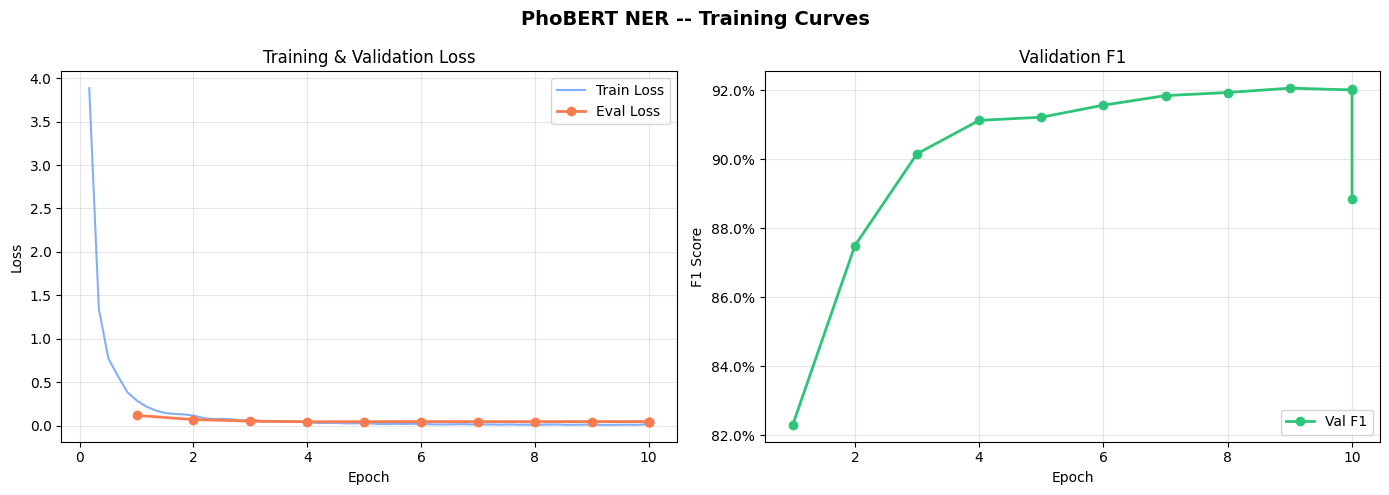

Saved: phobert-ner-vlsp2018/training_curves.png


In [21]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

log_history = trainer.state.log_history

# ── Separate train-step entries from eval entries ─────────────────────────────
# Both entry types carry an 'epoch' float field — use it as the common x-axis.
# (Plotting train loss by 'step' vs eval loss by 'epoch' causes x-scale mismatch)
train_entries  = [e for e in log_history if 'loss' in e and 'eval_loss' not in e]
eval_entries   = [e for e in log_history if 'eval_loss' in e]

train_epochs   = [e['epoch']     for e in train_entries]
train_losses   = [e['loss']      for e in train_entries]

eval_epochs    = [e['epoch']     for e in eval_entries]
eval_losses    = [e['eval_loss'] for e in eval_entries]

# F1 may not exist in every eval entry — keep epoch + f1 in sync
eval_f1_epochs = [e['epoch']   for e in eval_entries if 'eval_f1' in e]
eval_f1s       = [e['eval_f1'] for e in eval_entries if 'eval_f1' in e]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PhoBERT NER -- Training Curves', fontsize=14, fontweight='bold')

# ── Left: Loss (train + eval on the SAME axis, same x-scale = epoch) ─────────
ax = axes[0]
ax.plot(train_epochs, train_losses,
        label='Train Loss', color='#4f8ef7', alpha=0.7, linewidth=1.5)
if eval_epochs and eval_losses:
    ax.plot(eval_epochs, eval_losses,
            label='Eval Loss', color='#f97b4f', marker='o', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training & Validation Loss')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)

# ── Right: Validation F1 ──────────────────────────────────────────────────────
ax = axes[1]
if eval_f1s:
    ax.plot(eval_f1_epochs, eval_f1s,
            color='#2ec47a', marker='o', linewidth=2, label='Val F1')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.legend(loc='lower right')
ax.set_xlabel('Epoch')
ax.set_ylabel('F1 Score')
ax.set_title('Validation F1')
ax.grid(alpha=0.3)

plt.tight_layout()
curve_path = str(OUTPUT_DIR / 'training_curves.png')
plt.savefig(curve_path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ' + curve_path)

## 11. Inference

In [17]:
from transformers import pipeline as hf_pipeline

BEST_MODEL_PATH = str(OUTPUT_DIR / 'best_model')

ner_pipeline = hf_pipeline(
    task='ner',
    model=BEST_MODEL_PATH,
    tokenizer=BEST_MODEL_PATH,
    aggregation_strategy='simple',   # merges B/I sub-words into one span
    device=0 if torch.cuda.is_available() else -1,
)
print('NER pipeline loaded.')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

NER pipeline loaded.


In [18]:
def predict_ner(text: str) -> None:
    """Run the NER pipeline and print a formatted table."""
    entities = ner_pipeline(text)
    print('Input : ' + text)
    if not entities:
        print('  (no entities found)')
    else:
        print(f'  {"Entity":<30}  {"Label":<6}  Score')
        print('  ' + '-' * 46)
        for ent in entities:
            print('  {:<30}  {:<6}  {:.3f}'.format(ent['word'], ent['entity_group'], ent['score']))
    print()


test_sentences = [
    'Nguyễn Phú Trọng là Tổng Bí thư Đảng Cộng sản Việt Nam.',
    'Hội nghị thượng đỉnh ASEAN được tổ chức tại Hà Nội vào tháng 11.',
    'Công ty Vingroup vừa ra mắt mẫu xe điện VinFast tại thị trường Mỹ.',
    'Đội tuyển bóng đá Việt Nam đã giành chiến thắng trước Thái Lan ở SEA Games.',
]

for sent in test_sentences:
    predict_ner(sent)
    print('-' * 50)

Input : Nguyễn Phú Trọng là Tổng Bí thư Đảng Cộng sản Việt Nam.
  Entity                          Label   Score
  ----------------------------------------------
  Nguyễn Phú Trọng                PER     0.988
  Đảng Cộng sản Việt Nam.         ORG     0.982

--------------------------------------------------
Input : Hội nghị thượng đỉnh ASEAN được tổ chức tại Hà Nội vào tháng 11.
  Entity                          Label   Score
  ----------------------------------------------
  ASEAN                           ORG     0.986
  Hà Nội                          LOC     0.988

--------------------------------------------------
Input : Công ty Vingroup vừa ra mắt mẫu xe điện VinFast tại thị trường Mỹ.
  Entity                          Label   Score
  ----------------------------------------------
  Vingroup                        ORG     0.703
  VinFast                         ORG     0.986

--------------------------------------------------
Input : Đội tuyển bóng đá Việt Nam đã giành chiến thắ

## 12. Error Analysis

In [19]:
def error_analysis(
    trainer,
    dataset,
    raw_data : List[List[Tuple[str, str]]],
    id2label : Dict[int, str],
    n_errors : int = 10,
) -> None:
    """Print sentences where predictions differ from gold labels."""
    pred_out = trainer.predict(dataset)
    preds    = np.argmax(pred_out.predictions, axis=2)   # (N, seq_len)
    labels   = pred_out.label_ids                        # (N, seq_len)

    errors_shown = 0
    for sent_idx in range(min(len(raw_data), len(preds))):
        words = [w for w, _ in raw_data[sent_idx]]
        gold  = [l for _, l in raw_data[sent_idx]]

        # Recover predicted word-level labels:
        # keep only the first sub-token of each word (label != -100)
        pred_word_labels = [
            id2label[p]
            for p, l in zip(preds[sent_idx], labels[sent_idx])
            if l != -100
        ]

        n = min(len(gold), len(pred_word_labels))
        if gold[:n] == pred_word_labels[:n]:
            continue  # perfect prediction, skip

        print('Sentence #{}'.format(sent_idx))
        print('  {:<22}  {:<10}  {:<10}  OK'.format('Word', 'Gold', 'Pred'))
        print('  ' + '-' * 50)
        for w, g, p in zip(words[:n], gold[:n], pred_word_labels[:n]):
            mark = '  ' if g == p else '>>'
            ok   = 'v' if g == p else 'X'
            print('{} {:<22}  {:<10}  {:<10}  {}'.format(mark, w, g, p, ok))
        print()

        errors_shown += 1
        if errors_shown >= n_errors:
            break


print('=== Error Analysis — Test Set (first 5 mistakes) ===')
error_analysis(trainer, dataset_dict['test'], test_data, ID2LABEL, n_errors=5)

=== Error Analysis — Test Set (first 5 mistakes) ===
Sentence #3
  Word                    Gold        Pred        OK
  --------------------------------------------------
   Theo                    O           O           v
   ông                     O           O           v
   Chris                   B-PER       B-PER       v
   Chelliah                I-PER       I-PER       v
   ,                       O           O           v
   Phó                     O           O           v
   chủ                     O           O           v
   tịch                    O           O           v
   kiêm                    O           O           v
   Kiến                    O           O           v
   trúc                    O           O           v
   sư                      O           O           v
   trưởng                  O           O           v
   mảng                    O           O           v
   Công                    O           O           v
   nghệ                    O      

## 13. Save Results

In [20]:
summary = {
    'model':         MODEL_NAME,
    'max_length':    MAX_LENGTH,
    'batch_size':    BATCH_SIZE,
    'grad_accum':    GRAD_ACCUM,
    'learning_rate': LEARNING_RATE,
    'num_epochs':    NUM_EPOCHS,
    'device':        str(DEVICE),
    'data': {
        'train': len(train_data),
        'dev':   len(dev_data),
        'test':  len(test_data),
    },
    'dev_results': {
        'precision': dev_results.get('eval_precision'),
        'recall':    dev_results.get('eval_recall'),
        'f1':        dev_results.get('eval_f1'),
    },
    'test_results': {
        'precision': test_results.get('eval_precision'),
        'recall':    test_results.get('eval_recall'),
        'f1':        test_results.get('eval_f1'),
    },
    'per_entity_test': {
        etype: test_detailed.get(etype, {})
        for etype in ['PER', 'ORG', 'LOC', 'MISC']
    },
}

out_path = str(OUTPUT_DIR / 'results_summary.json')
with open(out_path, 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2, default=str)

print('Saved: ' + out_path)
print(json.dumps(summary, indent=2, default=str, ensure_ascii=False))

Saved: phobert-ner-vlsp2018/results_summary.json
{
  "model": "vinai/phobert-base-v2",
  "max_length": 256,
  "batch_size": 16,
  "grad_accum": 2,
  "learning_rate": 3e-05,
  "num_epochs": 10,
  "device": "cuda",
  "data": {
    "train": 9493,
    "dev": 3205,
    "test": 4258
  },
  "dev_results": {
    "precision": 0.9110944527736132,
    "recall": 0.9300581573308846,
    "f1": 0.9204786428355044
  },
  "test_results": {
    "precision": 0.8704745596868885,
    "recall": 0.9073176950535441,
    "f1": 0.8885143570536829
  },
  "per_entity_test": {
    "PER": {
      "precision": 0.9248538825494016,
      "recall": 0.9643064422518862,
      "f1": 0.9441682057110384,
      "number": "3446"
    },
    "ORG": {
      "precision": 0.8404597701149426,
      "recall": 0.8659403126480341,
      "f1": 0.8530097993467102,
      "number": "2111"
    },
    "LOC": {
      "precision": 0.8693737769080235,
      "recall": 0.8920682730923695,
      "f1": 0.8805748265609515,
      "number": "1992"
  